# HL-MMAT: Hybrid Lightweight Multi-Modal Attention Transformer
### Weed Classification — 10 Classes | Kaggle P100 GPU
---

## Cell 1 — Imports & Reproducibility

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Cell 2 — Configuration

In [2]:
class CFG:
    DATA_DIR     = "/kaggle/input/datasets/kamranhasanonik/weed-dataset-lastupdated"
    NUM_CLASSES  = 10
    IMG_SIZE     = 224
    BATCH_SIZE   = 32
    NUM_EPOCHS   = 30
    LR           = 1e-4
    WEIGHT_DECAY = 1e-5
    PATIENCE     = 7          # early-stopping patience
    BEST_MODEL   = "best_hlmmat.pth"

    TRAIN_SPLIT  = 0.70
    VAL_SPLIT    = 0.15
    # test = 1 - TRAIN_SPLIT - VAL_SPLIT = 0.15

print("Configuration loaded.")

Configuration loaded.


## Cell 3 — Data Transforms & DataLoaders

In [3]:
# ── Transforms ───────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ── Load dataset ─────────────────────────────────────────────────────────
full_dataset = datasets.ImageFolder(root=CFG.DATA_DIR, transform=train_transform)
CLASS_NAMES  = full_dataset.classes
print(f"Classes ({CFG.NUM_CLASSES}): {CLASS_NAMES}")
print(f"Total samples: {len(full_dataset)}")

# ── Split sizes ───────────────────────────────────────────────────────────
n_total = len(full_dataset)
n_train = int(n_total * CFG.TRAIN_SPLIT)
n_val   = int(n_total * CFG.VAL_SPLIT)
n_test  = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# Override transforms so val/test are never augmented
val_ds.dataset  = datasets.ImageFolder(root=CFG.DATA_DIR, transform=val_test_transform)
test_ds.dataset = datasets.ImageFolder(root=CFG.DATA_DIR, transform=val_test_transform)

# ── DataLoaders ───────────────────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE,
                          shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

print("DataLoaders ready.")

Classes (10): ['alligator_weed', 'carpet_grass', 'cyperus_rotundus', 'duck_weed', 'four_leaf_clover', 'pygmy groundcherry', 'vegetable_fern', 'water_hyacinth', 'water_lettuce', 'water_lily']
Total samples: 4908
Train: 3435 | Val: 736 | Test: 737
DataLoaders ready.


## Cell 4 — HL-MMAT Model Architecture

In [4]:
# ── 4a: Channel Attention ─────────────────────────────────────────────────
class ChannelAttention(nn.Module):
    """Squeeze-and-Excitation style channel attention gate."""
    def __init__(self, in_channels: int, reduction: int = 16):
        super().__init__()
        mid = max(in_channels // reduction, 8)
        self.avg_pool  = nn.AdaptiveAvgPool2d(1)
        self.max_pool  = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, in_channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        scale   = self.sigmoid(avg_out + max_out).unsqueeze(-1).unsqueeze(-1)
        return x * scale


# ── 4b: Spatial Attention ─────────────────────────────────────────────────
class SpatialAttention(nn.Module):
    """7×7 convolutional spatial attention gate."""
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size,
                                 padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_map    = x.mean(dim=1, keepdim=True)
        max_map, _ = x.max(dim=1, keepdim=True)
        concat     = torch.cat([avg_map, max_map], dim=1)
        return x * self.sigmoid(self.conv(concat))


# ── 4c: Full CBAM ─────────────────────────────────────────────────────────
class CBAM(nn.Module):
    """Convolutional Block Attention Module (channel → spatial)."""
    def __init__(self, in_channels: int, reduction: int = 16, kernel_size: int = 7):
        super().__init__()
        self.channel = ChannelAttention(in_channels, reduction)
        self.spatial = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.spatial(self.channel(x))


# ── 4d: Transformer Encoder Block ─────────────────────────────────────────
class TransformerBlock(nn.Module):
    """Single Transformer encoder block (MHA + FFN + LayerNorm residuals)."""
    def __init__(self, d_model: int, nhead: int = 8,
                 dim_ff: int = 1024, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(d_model, nhead,
                                           dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ff(x))
        return x


# ── 4e: HL-MMAT ───────────────────────────────────────────────────────────
class HLMMAT(nn.Module):
    """
    Hybrid Lightweight Multi-Modal Attention Transformer
    ─────────────────────────────────────────────────────
    Backbone : MobileNetV3-Large (pretrained)
    Attention: CBAM  (channel + spatial)
    Encoder  : 1-layer Transformer encoder
    Head     : FC → num_classes
    """
    def __init__(self, num_classes: int = 10, nhead: int = 8, dropout: float = 0.3):
        super().__init__()

        # Backbone — MobileNetV3-Large feature extractor
        backbone = models.mobilenet_v3_large(
            weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
        )
        self.feature_extractor = backbone.features    # → (B, 960, 7, 7)
        self.d_model = 960

        # CBAM attention
        self.cbam = CBAM(in_channels=self.d_model)

        # Pool spatial dims to 4×4 (= 16 tokens)
        self.pool = nn.AdaptiveAvgPool2d(4)

        # Transformer encoder
        self.transformer = TransformerBlock(
            d_model=self.d_model, nhead=nhead,
            dim_ff=self.d_model * 2, dropout=dropout
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.d_model),
            nn.Linear(self.d_model, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.feature_extractor(x)           # (B, 960, 7, 7)
        x = self.cbam(x)                        # (B, 960, 7, 7)
        x = self.pool(x)                        # (B, 960, 4, 4)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)        # (B, 16, 960)
        x = self.transformer(x)                 # (B, 16, 960)
        x = x.mean(dim=1)                       # (B, 960)
        return self.classifier(x)               # (B, num_classes)


# ── Instantiate & sanity check ────────────────────────────────────────────
model = HLMMAT(num_classes=CFG.NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {train_params:,}")

with torch.no_grad():
    dummy = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f"Output shape    : {out.shape}  ✓")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 141MB/s]


Total params    : 10,969,692
Trainable params: 10,969,692
Output shape    : torch.Size([2, 10])  ✓


## Cell 5 — Loss, Optimizer & Scheduler

In [5]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    model.parameters(),
    lr=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY
)

# Cosine annealing — smooth LR decay to eta_min over NUM_EPOCHS
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG.NUM_EPOCHS, eta_min=1e-6
)

print("Loss / Optimizer / Scheduler ready.")

Loss / Optimizer / Scheduler ready.


## Cell 6 — Train & Evaluate Helpers

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    """One full pass over the training set."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluate model — returns (loss, accuracy)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, 100.0 * correct / total

print("Helper functions defined.")

Helper functions defined.


## Cell 7 — Training Loop (Early Stopping + Best Model Save)

In [7]:
history = {
    "train_loss": [], "val_loss": [],
    "train_acc" : [], "val_acc" : [],
}

best_val_acc   = 0.0
patience_count = 0

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>9} | {'Val Acc':>8} | {'LR':>8}")
print("-" * 66)

for epoch in range(1, CFG.NUM_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2f}% | "
          f"{val_loss:>9.4f} | {val_acc:>7.2f}% | {current_lr:>8.2e}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CFG.BEST_MODEL)
        patience_count = 0
        print(f"          ✔ Best model saved  (val_acc={best_val_acc:.2f}%)")
    else:
        patience_count += 1

    # Early stopping
    if patience_count >= CFG.PATIENCE:
        print(f"\nEarly stopping after {epoch} epochs "
              f"(no improvement for {CFG.PATIENCE} epochs).")
        break

print(f"\nTraining complete. Best Val Acc: {best_val_acc:.2f}%")

 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |       LR
------------------------------------------------------------------
     1 |     0.9341 |    85.09% |    0.6467 |   96.60% | 9.97e-05
          ✔ Best model saved  (val_acc=96.60%)
     2 |     0.5800 |    98.69% |    0.5372 |   99.32% | 9.89e-05
          ✔ Best model saved  (val_acc=99.32%)
     3 |     0.5457 |    99.53% |    0.5260 |   99.32% | 9.76e-05
     4 |     0.5373 |    99.59% |    0.5146 |   99.86% | 9.57e-05
          ✔ Best model saved  (val_acc=99.86%)
     5 |     0.5278 |    99.71% |    0.5191 |   99.46% | 9.34e-05
     6 |     0.5212 |    99.80% |    0.5118 |   99.86% | 9.05e-05
     7 |     0.5180 |    99.94% |    0.5106 |   99.59% | 8.73e-05
     8 |     0.5194 |    99.77% |    0.5127 |   99.59% | 8.36e-05
     9 |     0.5156 |    99.94% |    0.5079 |   99.59% | 7.96e-05
    10 |     0.5126 |    99.97% |    0.5076 |   99.73% | 7.52e-05
    11 |     0.5122 |    99.97% |    0.5082 |   99.59% | 7.06e-05


## Cell 8 — Training Curves

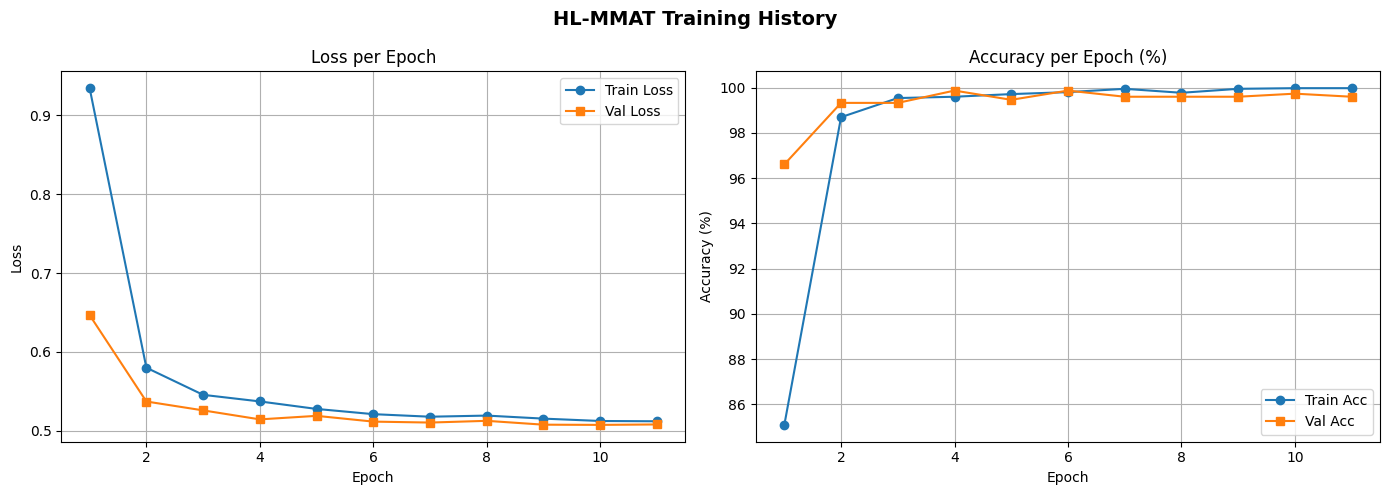

Saved → training_curves.png


In [8]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val Loss",   marker="s")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_ran, history["train_acc"], label="Train Acc", marker="o")
axes[1].plot(epochs_ran, history["val_acc"],   label="Val Acc",   marker="s")
axes[1].set_title("Accuracy per Epoch (%)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(True)

plt.suptitle("HL-MMAT Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → training_curves.png")

## Cell 9 — Load Best Model & Test Set Evaluation

In [9]:
# Load the best checkpoint
model.load_state_dict(torch.load(CFG.BEST_MODEL, map_location=DEVICE))
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Acc  : {test_acc:.2f}%")

Test Loss : 0.5199
Test Acc  : 99.73%


## Cell 10 — Classification Report

In [10]:
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        preds  = model(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("Classification Report:\n")
print(classification_report(all_labels, all_preds,
                            target_names=CLASS_NAMES, digits=4))

Classification Report:

                    precision    recall  f1-score   support

    alligator_weed     0.9873    1.0000    0.9936        78
      carpet_grass     0.9868    0.9868    0.9868        76
  cyperus_rotundus     1.0000    1.0000    1.0000        75
         duck_weed     1.0000    1.0000    1.0000        84
  four_leaf_clover     1.0000    0.9846    0.9922        65
pygmy groundcherry     1.0000    1.0000    1.0000        74
    vegetable_fern     1.0000    1.0000    1.0000        71
    water_hyacinth     1.0000    1.0000    1.0000        74
     water_lettuce     1.0000    1.0000    1.0000        70
        water_lily     1.0000    1.0000    1.0000        70

          accuracy                         0.9973       737
         macro avg     0.9974    0.9971    0.9973       737
      weighted avg     0.9973    0.9973    0.9973       737



## Cell 11 — Confusion Matrix

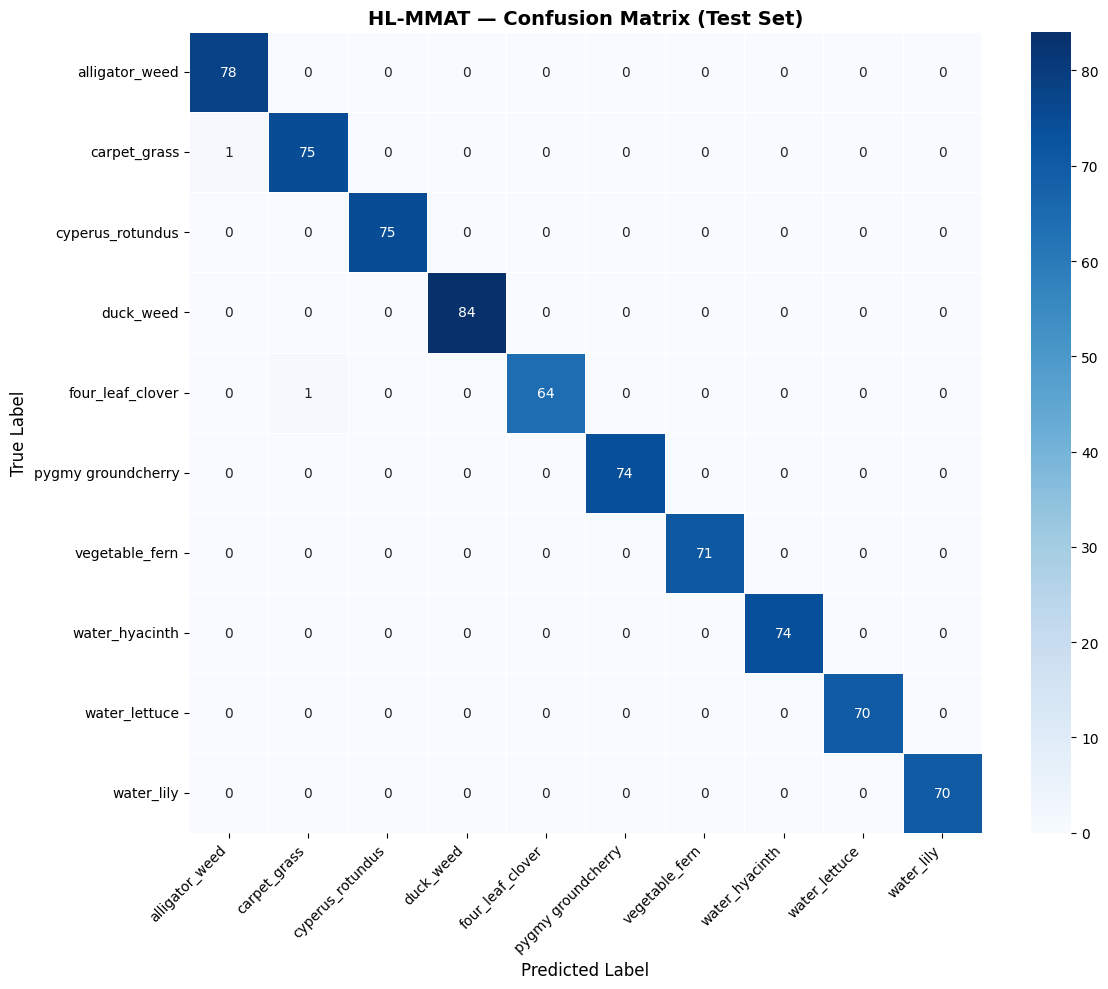

Saved → confusion_matrix.png

All done. ✅


In [11]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label",      fontsize=12)
ax.set_title("HL-MMAT — Confusion Matrix (Test Set)",
             fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → confusion_matrix.png")
print("\nAll done. ✅")

# Cell 12 — t-SNE Feature Visualisation

Feature matrix shape: (737, 960)
Running t-SNE …  (this may take ~30-60 s)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_55/2873016099.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", CFG.NUM_CLASSES)


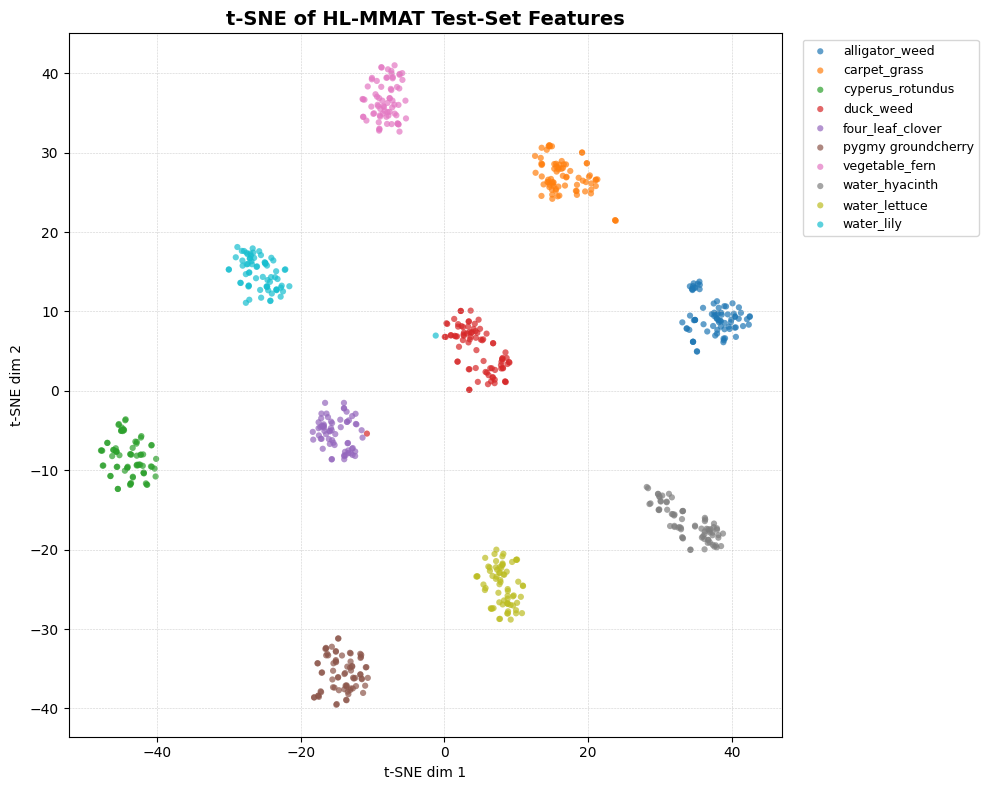

Saved → tsne.png


In [12]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch

# ── Extract penultimate-layer features from the test set ─────────────────
model.eval()

features_list = []
labels_list   = []

# Hook to capture the output just before the final linear layer
def hook_fn(module, input, output):
    features_list.append(output.detach().cpu().numpy())

# Register hook on the LayerNorm before the classifier head
hook = model.classifier[0].register_forward_hook(hook_fn)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        _      = model(images)          # forward pass triggers the hook
        labels_list.append(labels.numpy())

hook.remove()

features = np.concatenate(features_list, axis=0)   # (N, 960)
labels   = np.concatenate(labels_list,   axis=0)   # (N,)

print(f"Feature matrix shape: {features.shape}")

# ── Run t-SNE ─────────────────────────────────────────────────────────────
print("Running t-SNE …  (this may take ~30-60 s)")
tsne    = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
emb     = tsne.fit_transform(features)              # (N, 2)

# ── Plot ──────────────────────────────────────────────────────────────────
palette = plt.cm.get_cmap("tab10", CFG.NUM_CLASSES)

fig, ax = plt.subplots(figsize=(10, 8))
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = labels == cls_idx
    ax.scatter(emb[mask, 0], emb[mask, 1],
               c=[palette(cls_idx)], label=cls_name,
               alpha=0.7, s=20, edgecolors="none")

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.set_title("t-SNE of HL-MMAT Test-Set Features", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
plt.tight_layout()
plt.savefig("tsne.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tsne.png")
